In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
from pathlib import Path
import re

# Path to the 0° direct-view spectrum file (relative to notebook location)
mca_path = Path('111B_COM_data_jsyb/scattering_data/omar_rishab_0_sig.mca')

# Read full MCA text
text = mca_path.read_text(encoding='utf-8', errors='replace')

# Parse key scalar values from header/status blocks
slow_count_match = re.search(r'^Slow Count:\s*(\d+)', text, flags=re.MULTILINE)
live_time_match = re.search(r'^LIVE_TIME\s*-\s*([0-9.]+)', text, flags=re.MULTILINE)
real_time_match = re.search(r'^REAL_TIME\s*-\s*([0-9.]+)', text, flags=re.MULTILINE)

if not (slow_count_match and live_time_match and real_time_match):
    raise ValueError('Could not parse Slow Count / LIVE_TIME / REAL_TIME from the .mca file.')

slow_count = int(slow_count_match.group(1))
live_time_s = float(live_time_match.group(1))
real_time_s = float(real_time_match.group(1))

# Also parse the DATA block and sum channels (sanity check)
data_block_match = re.search(r'<<DATA>>\s*(.*?)\s*<<END>>', text, flags=re.DOTALL)
if data_block_match:
    channel_counts = [int(x) for x in data_block_match.group(1).split() if re.fullmatch(r'\d+', x)]
    data_sum = sum(channel_counts)
    n_channels = len(channel_counts)
else:
    data_sum = None
    n_channels = 0

# Rates
rate_live_cps = slow_count / live_time_s   # dead-time-corrected detector event rate
rate_real_cps = slow_count / real_time_s   # wall-clock average rate

print(f'Reading MCA file: {mca_path}')
print('Parsed header/status values:')
print(f'  Slow Count = {slow_count:,d} events')
print(f'  LIVE_TIME  = {live_time_s:.6f} s')
print(f'  REAL_TIME  = {real_time_s:.6f} s')

if data_sum is not None:
    print('')
    print('DATA block sanity check:')
    print(f'  Number of channels parsed = {n_channels}')
    print(f'  Sum of channel counts     = {data_sum:,d} events')

print('')
print('Event count/time results:')
print(f'  Live-time rate  = N / LIVE_TIME = {rate_live_cps:.4f} counts/s')


Reading MCA file: 111B_COM_data_jsyb/scattering_data/omar_rishab_0_sig.mca
Parsed header/status values:
  Slow Count = 256,160 events
  LIVE_TIME  = 6529.934326 s
  REAL_TIME  = 79828.048000 s

DATA block sanity check:
  Number of channels parsed = 2048
  Sum of channel counts     = 256,160 events

Event count/time results:
  Live-time rate  = N / LIVE_TIME = 39.2286 counts/s


In [3]:
from pathlib import Path
import re
import numpy as np

print('Step 1: Use the new calibration run taken at your effective ~16.76 gain setting.')
cal_file = Path('111B_COM_data_jsyb/calibration_curve_data/omar_rishab_0_calib_1676e-2_gain.mca')
print(f'  Calibration file: {cal_file}')

print('\nStep 2: Read the MCA text and parse spectrum data + gain settings.')
cal_text = cal_file.read_text(encoding='utf-8', errors='replace')

data_match = re.search(r'<<DATA>>\s*(.*?)\s*<<END>>', cal_text, flags=re.DOTALL)
if not data_match:
    raise ValueError('No <<DATA>> block found in calibration file.')

counts = np.array([int(x) for x in data_match.group(1).split() if re.fullmatch(r'\d+', x)], dtype=float)
num_channels = len(counts)

coarse_match = re.search(r'^Coarse Gain:\s*([0-9.]+)x', cal_text, flags=re.MULTILINE)
fine_match = re.search(r'^Fine Gain:\s*([0-9.]+)', cal_text, flags=re.MULTILINE)
coarse_gain = float(coarse_match.group(1)) if coarse_match else np.nan
fine_gain = float(fine_match.group(1)) if fine_match else np.nan
effective_gain = coarse_gain * fine_gain

print(f'  Parsed channels: {num_channels}')
print(f'  Coarse gain: {coarse_gain:.4f}x')
print(f'  Fine gain:   {fine_gain:.4f}')
print(f'  Effective gain (coarse*fine): {effective_gain:.4f}x')

print('\nStep 3: Smooth the spectrum to stabilize peak finding.')
kernel = np.ones(7, dtype=float) / 7.0
smooth = np.convolve(counts, kernel, mode='same')

print('\nStep 4: Find the 59.54 keV photopeak in the high-channel region.')
high_start = max(200, int(0.45 * num_channels))
photo_rel = int(np.argmax(smooth[high_start:]))
photo_ch = high_start + photo_rel
print(f'  Estimated 59.54 keV photopeak channel: {photo_ch}')

print('\nStep 5: Match multiple Am-241 lines and fit E = m*channel + b.')
known_energies_keV = np.array([13.95, 17.75, 20.78, 26.34, 59.54], dtype=float)

m_guess = 59.54 / photo_ch
matched_channels = []
for E in known_energies_keV:
    pred = int(round(E / m_guess))
    half_window = max(8, int(0.015 * num_channels))
    lo = max(0, pred - half_window)
    hi = min(num_channels, pred + half_window + 1)
    local_rel = int(np.argmax(smooth[lo:hi]))
    ch = lo + local_rel
    matched_channels.append(ch)

matched_channels = np.array(matched_channels, dtype=float)

m_fit, b_fit = np.polyfit(matched_channels, known_energies_keV, 1)
fit_vals = m_fit * matched_channels + b_fit
ss_res = np.sum((known_energies_keV - fit_vals) ** 2)
ss_tot = np.sum((known_energies_keV - np.mean(known_energies_keV)) ** 2)
r2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)

print('  Matched (energy keV -> channel):')
for E, ch in zip(known_energies_keV, matched_channels):
    print(f'    {E:6.2f} keV -> ch {int(ch)}')

print('\nStep 6: Report calibration and bin width results.')
print(f'  Multi-line fit: E = ({m_fit:.6f})*channel + ({b_fit:.3f}) keV')
print(f'  Bin width from multi-line fit: {m_fit:.6f} keV/channel')
print(f'  Fit quality R^2: {r2:.6f}')

m_one_point = 59.54 / photo_ch
print(f'  One-point bin width check (59.54/photo_ch): {m_one_point:.6f} keV/channel')

print('\nStep 7: Build calibrated energy axis for later plots.')
energy_axis_keV = m_fit * np.arange(num_channels) + b_fit
energy_min = float(energy_axis_keV[0])
energy_max = float(energy_axis_keV[-1])
full_scale_keV = energy_max - energy_min

print(f'  x-axis units after calibration: keV')
print(f'  Calibrated axis start: {energy_min:.3f} keV')
print(f'  Calibrated axis end:   {energy_max:.3f} keV')
print(f'  Full calibrated range: {full_scale_keV:.3f} keV')
print('  Calibration complete for the ~16.76 effective gain run.')

Step 1: Use the new calibration run taken at your effective ~16.76 gain setting.
  Calibration file: 111B_COM_data_jsyb/calibration_curve_data/omar_rishab_0_calib_1676e-2_gain.mca

Step 2: Read the MCA text and parse spectrum data + gain settings.
  Parsed channels: 2048
  Coarse gain: 17.7700x
  Fine gain:   0.9434
  Effective gain (coarse*fine): 16.7642x

Step 3: Smooth the spectrum to stabilize peak finding.

Step 4: Find the 59.54 keV photopeak in the high-channel region.
  Estimated 59.54 keV photopeak channel: 1729

Step 5: Match multiple Am-241 lines and fit E = m*channel + b.
  Matched (energy keV -> channel):
     13.95 keV -> ch 411
     17.75 keV -> ch 522
     20.78 keV -> ch 610
     26.34 keV -> ch 771
     59.54 keV -> ch 1729

Step 6: Report calibration and bin width results.
  Multi-line fit: E = (0.034612)*channel + (-0.315) keV
  Bin width from multi-line fit: 0.034612 keV/channel
  Fit quality R^2: 0.999998
  One-point bin width check (59.54/photo_ch): 0.034436 keV/

In [4]:
from pathlib import Path
import re
import numpy as np

print('Defining reusable functions for calibrated, live-time-scaled background subtraction.')


def read_mca_counts_and_live_time(file_path):
    """Read one .mca file and return channel counts and LIVE_TIME.

    What this function does:
    1. Loads the raw text from the MCA file.
    2. Extracts channel counts from the <<DATA>> block.
    3. Extracts LIVE_TIME from the header.
    4. Returns both so we can normalize/subtract spectra correctly.
    """
    file_path = Path(file_path)
    text = file_path.read_text(encoding='utf-8', errors='replace')

    data_match = re.search(r'<<DATA>>\s*(.*?)\s*<<END>>', text, flags=re.DOTALL)
    if not data_match:
        raise ValueError(f'No <<DATA>> block found in {file_path}')

    counts = np.array([int(x) for x in data_match.group(1).split() if re.fullmatch(r'\d+', x)], dtype=float)

    live_match = re.search(r'^LIVE_TIME\s*-\s*([0-9.]+)', text, flags=re.MULTILINE)
    if not live_match:
        raise ValueError(f'No LIVE_TIME found in {file_path}')

    live_time_s = float(live_match.group(1))
    return counts, live_time_s



def build_energy_axis(num_channels, slope_keV_per_channel, intercept_keV):
    """Build calibrated x-axis in keV using E(channel) = m*channel + b."""
    channels = np.arange(num_channels, dtype=float)
    return slope_keV_per_channel * channels + intercept_keV



def subtract_background_scaled(sig_path, bkg_path, slope_keV_per_channel, intercept_keV):
    """Background-subtract one signal/background pair with live-time scaling.

    Formula used per channel i:
        net(i) = sig(i) - (t_sig / t_bkg) * bkg(i)
    """
    sig_counts, sig_live = read_mca_counts_and_live_time(sig_path)
    bkg_counts, bkg_live = read_mca_counts_and_live_time(bkg_path)

    if len(sig_counts) != len(bkg_counts):
        raise ValueError('Signal and background files have different channel counts.')

    scale = sig_live / bkg_live
    bkg_scaled = bkg_counts * scale
    net_counts = sig_counts - bkg_scaled
    energy_keV = build_energy_axis(len(sig_counts), slope_keV_per_channel, intercept_keV)

    return {
        'sig_path': str(sig_path),
        'bkg_path': str(bkg_path),
        'sig_live_s': sig_live,
        'bkg_live_s': bkg_live,
        'scale': scale,
        'energy_keV': energy_keV,
        'sig_counts': sig_counts,
        'bkg_counts_scaled': bkg_scaled,
        'net_counts': net_counts,
    }


print('\nUsing calibration from the previous cell (m_fit, b_fit).')
slope_m = float(m_fit)
intercept_b = float(b_fit)
print(f'  Calibration equation: E = ({slope_m:.6f})*channel + ({intercept_b:.3f}) keV')

base = Path('111B_COM_data_jsyb/scattering_data')
pairs = {
    30: (base / 'omar_rishab_30_sig.mca', base / 'omar_rishab_30_bkg.mca'),
    60: (base / 'omar_rishab_60_sig.mca', base / 'omar_rishab_60_bkg.mca'),
    100: (base / 'omar_rishabh_100_sig.mca', base / 'omar_rishabh_100_bkg.mca'),
    120: (base / 'omar_rishab_120_sig.mca', base / 'omar_rishab_120_bkg.mca'),
}

print('\nRunning scaled subtraction for 30, 60, 100, and 120 deg...')
subtracted_results = {}
for angle_deg, (sig_file, bkg_file) in pairs.items():
    result = subtract_background_scaled(sig_file, bkg_file, slope_m, intercept_b)
    subtracted_results[angle_deg] = result

    print(f'\nAngle {angle_deg} deg:')
    print(f'  Signal file:      {sig_file.name}')
    print(f'  Background file:  {bkg_file.name}')
    print(f'  LIVE_TIME signal: {result["sig_live_s"]:.3f} s')
    print(f'  LIVE_TIME bkg:    {result["bkg_live_s"]:.3f} s')
    print(f'  Background scale (t_sig/t_bkg): {result["scale"]:.6f}')
    print('  Subtraction used scaled background: net = sig - (t_sig/t_bkg)*bkg')
    print(f'  Net counts sum (all channels): {np.sum(result["net_counts"]):.2f}')

print('\nDone. Results stored in dictionary: subtracted_results')
print('Each entry contains: energy_keV, sig_counts, bkg_counts_scaled, net_counts, and timing metadata.')

Defining reusable functions for calibrated, live-time-scaled background subtraction.

Using calibration from the previous cell (m_fit, b_fit).
  Calibration equation: E = (0.034612)*channel + (-0.315) keV

Running scaled subtraction for 30, 60, 100, and 120 deg...

Angle 30 deg:
  Signal file:      omar_rishab_30_sig.mca
  Background file:  omar_rishab_30_bkg.mca
  LIVE_TIME signal: 246.824 s
  LIVE_TIME bkg:    1448.755 s
  Background scale (t_sig/t_bkg): 0.170369
  Subtraction used scaled background: net = sig - (t_sig/t_bkg)*bkg
  Net counts sum (all channels): 469.00

Angle 60 deg:
  Signal file:      omar_rishab_60_sig.mca
  Background file:  omar_rishab_60_bkg.mca
  LIVE_TIME signal: 4726.142 s
  LIVE_TIME bkg:    427.445 s
  Background scale (t_sig/t_bkg): 11.056718
  Subtraction used scaled background: net = sig - (t_sig/t_bkg)*bkg
  Net counts sum (all channels): -19173.66

Angle 100 deg:
  Signal file:      omar_rishabh_100_sig.mca
  Background file:  omar_rishabh_100_bkg.mca

Step 1: Define a helper to fit a Gaussian centroid in a chosen energy window.

Step 2: Extract peak energies from background-subtracted spectra (Gaussian centroid method).
  Angle  30 deg -> centroid 58.269 keV (sigma 1.649 keV, peak height 6.47)
  Angle  60 deg -> centroid 56.369 keV (sigma 1.863 keV, peak height 17.77)
  Angle 100 deg -> centroid 51.166 keV (sigma 2.140 keV, peak height 21.26)
  Angle 120 deg -> centroid 50.071 keV (sigma 1.603 keV, peak height 32.90)

Step 3: Build Compton linearization axis x = 1 - cos(theta).
  cos(theta) values: [np.float64(0.866025), np.float64(0.5), np.float64(-0.173648), np.float64(-0.5)]
  1-cos(theta) values: [np.float64(0.133975), np.float64(0.5), np.float64(1.173648), np.float64(1.5)]

Step 4: Define uncertainty arrays and transform to y = 1/E.
  Angle uncertainty stored for later use: +- 1.0 deg
  Energy uncertainty (input):             +- 0.034612 keV

Step 5: Fit y = 1/E versus x = 1-cos(theta).
  Linearized fit: 1/E = (0.00217531 +- 0.

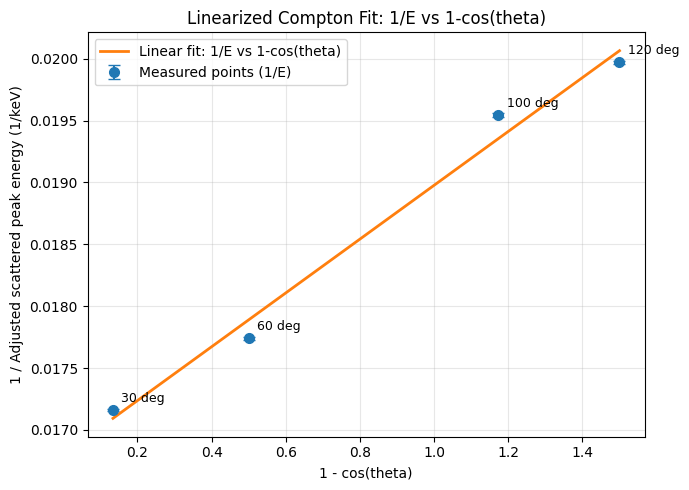


Done. Arrays available for later use:
  angles_deg, cos_theta, one_minus_cos_theta, peak_energies_keV, peak_heights
  peak_fit_details, angle_uncertainty_deg, energy_uncertainty_keV
  inv_energy_keV_inv, sigma_inv_energy
  fit_slope, fit_slope_err, fit_intercept, fit_intercept_err, fit_r2
  mc2_fit_keV, mc2_fit_unc_keV, E0_fit_keV, E0_fit_unc_keV


In [9]:
import numpy as np
import matplotlib.pyplot as plt

print('Step 1: Define a helper to fit a Gaussian centroid in a chosen energy window.')

def fit_peak_gaussian_centroid(energy_keV, net_counts, e_min=45.0, e_max=62.0):
    """Fit a Gaussian peak + constant background using a grid-search LS approach.

    Model: y(E) = A*exp(-0.5*((E-mu)/sigma)^2) + C
    Returns centroid mu, fitted peak height at mu, and a diagnostics dictionary.
    """
    mask = (energy_keV >= e_min) & (energy_keV <= e_max)
    if not np.any(mask):
        raise ValueError('No points found inside the requested energy window.')

    e_win = np.asarray(energy_keV[mask], dtype=float)
    c_win = np.asarray(net_counts[mask], dtype=float)

    if len(e_win) < 8:
        raise ValueError('Not enough points in peak window for Gaussian fitting.')

    # Robust initial estimates from background-subtracted positive content.
    c_floor = np.percentile(c_win, 20)
    y_pos = np.clip(c_win - c_floor, 0.0, None)

    if np.sum(y_pos) <= 0:
        idx = int(np.argmax(c_win))
        mu_fallback = float(e_win[idx])
        h_fallback = float(c_win[idx])
        return mu_fallback, h_fallback, {'method': 'fallback-argmax'}

    dE = float(np.median(np.diff(e_win)))
    mu0 = float(np.sum(e_win * y_pos) / np.sum(y_pos))
    var0 = float(np.sum(y_pos * (e_win - mu0) ** 2) / np.sum(y_pos))
    sigma0 = float(np.sqrt(max(var0, dE ** 2)))
    sigma0 = float(np.clip(sigma0, dE, 0.35 * (e_max - e_min)))

    # Coarse grid in (mu, sigma); for each pair solve optimal A, C by linear LS.
    mu_span = max(2.0 * sigma0, 3.0 * dE)
    mu_grid = np.linspace(mu0 - mu_span, mu0 + mu_span, 121)
    sigma_grid = np.linspace(max(dE, 0.4 * sigma0), 2.5 * sigma0, 80)

    best = {'sse': np.inf}

    for mu in mu_grid:
        for sigma in sigma_grid:
            g = np.exp(-0.5 * ((e_win - mu) / sigma) ** 2)
            X = np.column_stack((g, np.ones_like(g)))

            beta, _, _, _ = np.linalg.lstsq(X, c_win, rcond=None)
            A, C = float(beta[0]), float(beta[1])

            # Keep physically meaningful peak orientation.
            if A <= 0:
                continue

            y_fit = A * g + C
            sse = float(np.sum((c_win - y_fit) ** 2))

            if sse < best['sse']:
                best = {
                    'sse': sse,
                    'mu': float(mu),
                    'sigma': float(sigma),
                    'A': A,
                    'C': C,
                }

    if not np.isfinite(best['sse']):
        idx = int(np.argmax(c_win))
        mu_fallback = float(e_win[idx])
        h_fallback = float(c_win[idx])
        return mu_fallback, h_fallback, {'method': 'fallback-argmax'}

    peak_height = best['A'] + best['C']
    best['method'] = 'gaussian-grid-ls'

    return float(best['mu']), float(peak_height), best


print('\nStep 2: Extract peak energies from background-subtracted spectra (Gaussian centroid method).')
angles_deg = np.array(sorted(subtracted_results.keys()), dtype=float)
peak_energies_keV = []
peak_heights = []
peak_fit_details = {}

for angle in angles_deg:
    result = subtracted_results[int(angle)]
    energy = np.array(result['energy_keV'], dtype=float)
    net = np.array(result['net_counts'], dtype=float)

    peak_e, peak_h, fit_info = fit_peak_gaussian_centroid(energy, net, e_min=45.0, e_max=62.0)
    peak_energies_keV.append(peak_e)
    peak_heights.append(peak_h)
    peak_fit_details[int(angle)] = fit_info

    if fit_info.get('method') == 'gaussian-grid-ls':
        print(
            f"  Angle {int(angle):3d} deg -> centroid {peak_e:.3f} keV "
            f"(sigma {fit_info['sigma']:.3f} keV, peak height {peak_h:.2f})"
        )
    else:
        print(
            f"  Angle {int(angle):3d} deg -> fallback centroid {peak_e:.3f} keV "
            f"(peak height {peak_h:.2f})"
        )

peak_energies_keV = np.array(peak_energies_keV, dtype=float)
peak_heights = np.array(peak_heights, dtype=float)

print('\nStep 3: Build Compton linearization axis x = 1 - cos(theta).')
theta_rad = np.deg2rad(angles_deg)
cos_theta = np.cos(theta_rad)
one_minus_cos_theta = 1.0 - cos_theta
print(f'  cos(theta) values: {[round(x, 6) for x in cos_theta]}')
print(f'  1-cos(theta) values: {[round(x, 6) for x in one_minus_cos_theta]}')

print('\nStep 4: Define uncertainty arrays and transform to y = 1/E.')
# Keep angle uncertainty for later propagation in other analyses.
angle_uncertainty_deg = np.full_like(angles_deg, 1.0, dtype=float)

# Keep bin-width uncertainty as baseline peak-energy uncertainty.
energy_uncertainty_keV = np.full_like(peak_energies_keV, float(m_fit), dtype=float)

# Linearized Compton y-variable and propagated uncertainty: sigma_(1/E) = sigma_E / E^2.
inv_energy_keV_inv = 1.0 / peak_energies_keV
sigma_inv_energy = energy_uncertainty_keV / (peak_energies_keV**2)

print(f'  Angle uncertainty stored for later use: +- {angle_uncertainty_deg[0]:.1f} deg')
print(f'  Energy uncertainty (input):             +- {energy_uncertainty_keV[0]:.6f} keV')

print('\nStep 5: Fit y = 1/E versus x = 1-cos(theta).')
weights = 1.0 / sigma_inv_energy
(fit_slope, fit_intercept), fit_cov = np.polyfit(
    one_minus_cos_theta,
    inv_energy_keV_inv,
    1,
    w=weights,
    cov=True,
    )

fit_slope_err = float(np.sqrt(fit_cov[0, 0]))
fit_intercept_err = float(np.sqrt(fit_cov[1, 1]))

inv_energy_pred = fit_slope * one_minus_cos_theta + fit_intercept
ss_res = np.sum((inv_energy_keV_inv - inv_energy_pred) ** 2)
ss_tot = np.sum((inv_energy_keV_inv - np.mean(inv_energy_keV_inv)) ** 2)
fit_r2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)

mc2_fit_keV = 1.0 / fit_slope
mc2_fit_unc_keV = fit_slope_err / (fit_slope**2)
E0_fit_keV = 1.0 / fit_intercept
E0_fit_unc_keV = fit_intercept_err / (fit_intercept**2)

# Keep these names for compatibility with any downstream references.
fit_a = fit_slope
fit_b = fit_intercept

print(f'  Linearized fit: 1/E = ({fit_slope:.8f} +- {fit_slope_err:.8f})*(1-cos(theta)) + ({fit_intercept:.8f} +- {fit_intercept_err:.8f})')
print(f'  Fit R^2: {fit_r2:.6f}')
print(f'  Implied mc^2 from slope: {mc2_fit_keV:.3f} +- {mc2_fit_unc_keV:.3f} keV')
print(f'  Implied E0 from intercept: {E0_fit_keV:.3f} +- {E0_fit_unc_keV:.3f} keV')

print('\nStep 6: Plot 1/E versus 1-cos(theta) with weighted linear fit.')
plt.figure(figsize=(7, 5))

plt.errorbar(
    one_minus_cos_theta,
    inv_energy_keV_inv,
    yerr=sigma_inv_energy,
    fmt='o',
    markersize=7,
    capsize=4,
    label='Measured points (1/E)'
)

x_line = np.linspace(np.min(one_minus_cos_theta), np.max(one_minus_cos_theta), 200)
y_fit_line = fit_slope * x_line + fit_intercept
plt.plot(x_line, y_fit_line, '-', linewidth=2, label='Linear fit: 1/E vs 1-cos(theta)')

for x_val, y_val, a_deg in zip(one_minus_cos_theta, inv_energy_keV_inv, angles_deg):
    plt.annotate(f'{int(a_deg)} deg', (x_val, y_val), textcoords='offset points', xytext=(6, 6), fontsize=9)

plt.xlabel('1 - cos(theta)')
plt.ylabel('1 / Adjusted scattered peak energy (1/keV)')
plt.title('Linearized Compton Fit: 1/E vs 1-cos(theta)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('\nDone. Arrays available for later use:')
print('  angles_deg, cos_theta, one_minus_cos_theta, peak_energies_keV, peak_heights')
print('  peak_fit_details, angle_uncertainty_deg, energy_uncertainty_keV')
print('  inv_energy_keV_inv, sigma_inv_energy')
print('  fit_slope, fit_slope_err, fit_intercept, fit_intercept_err, fit_r2')
print('  mc2_fit_keV, mc2_fit_unc_keV, E0_fit_keV, E0_fit_unc_keV')

In [11]:
import numpy as np

print('Step 1: Define constants and pull measured energies + uncertainties from previous cells.')
E0_keV = 59.54  # Am-241 gamma energy used in this experiment (keV)

# Use measured background-subtracted peak energies (not the linear-in-theta model).
angles_deg_data = np.array(angles_deg, dtype=float)
energies_measured_keV = np.array(peak_energies_keV, dtype=float)

# Uncertainties requested previously.
sigma_E_keV = np.array(energy_uncertainty_keV, dtype=float)    # bin-width uncertainty
sigma_theta_deg = np.array(angle_uncertainty_deg, dtype=float) # angle uncertainty
sigma_theta_rad = np.deg2rad(sigma_theta_deg)

theta_rad = np.deg2rad(angles_deg_data)

print(f'  Using E0 = {E0_keV:.2f} keV')
print(f'  Angles (deg): {angles_deg_data.tolist()}')
print(f'  Measured peak energies (keV): {[round(x, 4) for x in energies_measured_keV]}')
print(f'  sigma_E (keV): {[round(x, 6) for x in sigma_E_keV]}')
print(f'  sigma_theta (deg): {[round(x, 3) for x in sigma_theta_deg]}')

print('\nStep 2: Compute mc^2 from full Compton relation (depends on cos(theta)).')
print('        Formula: E(theta) = E0 / [1 + (E0/mc^2)*(1-cos(theta))]')
print('        Rearranged: mc^2 = E0*(1-cos(theta)) / (E0/E - 1)')

A = E0_keV * (1.0 - np.cos(theta_rad))
B = (E0_keV / energies_measured_keV) - 1.0
mc2_keV_each = A / B

print('  Per-angle mc^2 estimates (keV):')
for a_deg, mc2_val in zip(angles_deg_data, mc2_keV_each):
    print(f'    angle {a_deg:6.1f} deg -> mc^2 = {mc2_val:.3f} keV')

print('\nStep 3: Propagate uncertainty from energy and angle (first-order).')
print('        sigma_mc2^2 = (dmc2/dE * sigma_E)^2 + (dmc2/dtheta * sigma_theta)^2')

# Partial derivatives for mc^2 = A/B, with A=E0(1-cos(theta)), B=E0/E - 1
# d(mc2)/dE = A*E0 / (E^2 * B^2)
# d(mc2)/dtheta = E0*sin(theta) / B   (theta in radians)
dmc2_dE = A * E0_keV / (energies_measured_keV**2 * B**2)
dmc2_dtheta = E0_keV * np.sin(theta_rad) / B

sigma_mc2_keV_each = np.sqrt((dmc2_dE * sigma_E_keV)**2 + (dmc2_dtheta * sigma_theta_rad)**2)

print('  Per-angle mc^2 uncertainties (keV):')
for a_deg, s_val in zip(angles_deg_data, sigma_mc2_keV_each):
    print(f'    angle {a_deg:6.1f} deg -> sigma_mc^2 = {s_val:.3f} keV')

print('\nStep 4: Combine per-angle values with inverse-variance weighting.')
weights = 1.0 / (sigma_mc2_keV_each**2)
mc2_keV_weighted = np.sum(weights * mc2_keV_each) / np.sum(weights)
sigma_mc2_keV_weighted = np.sqrt(1.0 / np.sum(weights))

print(f'  Weighted mc^2 = {mc2_keV_weighted:.3f} +- {sigma_mc2_keV_weighted:.3f} keV')

print('\nStep 5: Convert mc^2 to electron mass in kg.')
e_charge = 1.602176634e-19  # J/eV
c = 299792458.0              # m/s

# keV -> eV -> J, then m = (mc^2)/c^2
me_kg = (mc2_keV_weighted * 1e3 * e_charge) / (c**2)
sigma_me_kg = (sigma_mc2_keV_weighted * 1e3 * e_charge) / (c**2)

me_true_kg = 9.1093837015e-31
me_true_mc2_keV = 510.99895

print(f'  Estimated electron mass: m_e = {me_kg:.6e} +- {sigma_me_kg:.2e} kg')
print(f'  Reference electron mass: m_e,true = {me_true_kg:.6e} kg')
print(f'  Estimated mc^2: {mc2_keV_weighted:.3f} +- {sigma_mc2_keV_weighted:.3f} keV')
print(f'  Reference mc^2: {me_true_mc2_keV:.3f} keV')

percent_error = 100.0 * abs(mc2_keV_weighted - me_true_mc2_keV) / me_true_mc2_keV
print(f'  Percent error in mc^2 vs reference: {percent_error:.2f}%')

print('\nNote: This now uses measured peak energies and full cos(theta) dependence.')
print('      Included uncertainties: bin-width energy uncertainty and +-1 deg angle uncertainty.')

Step 1: Collect constants and measured peak-energy inputs from previous cells.
  Angles (deg): [30.0, 60.0, 100.0, 120.0]
  Measured peak energies (keV): [np.float64(58.269), np.float64(56.3688), np.float64(51.1665), np.float64(50.0709)]
  sigma_E (keV): [np.float64(0.034612), np.float64(0.034612), np.float64(0.034612), np.float64(0.034612)]
  sigma_theta (deg): [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]

Step 2: Primary estimate from GLOBAL linearized fit (preferred).
        Uses Cell 5 fit: 1/E = slope*(1-cos(theta)) + intercept
        Therefore mc^2 = 1/slope and E0 = 1/intercept
  PRIMARY mc^2 (global slope-based): 459.705 +- 36.578 keV
  PRIMARY m_e (global slope-based):  8.194992e-31 +- 6.52e-32 kg
  Fitted E0 from intercept:          59.518 +- 0.533 keV

Step 3: Comparison estimate (older method): per-angle mc^2 then weighted average.
        This is what "as opposed to what" means in your note.
        It computes mc^2 at each angle first, then avera